# Credit Card Fraud Detection - Model Training
## SMOTE and XGBoost Implementation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

In [3]:
# Load preprocessed data
import joblib

X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_test = joblib.load('../data/y_test.pkl')

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'\nTraining Fraud cases: {y_train.sum()}')
print(f'Test Fraud cases: {y_test.sum()}')

Train shape: (227845, 30)
Test shape: (56962, 30)

Training Fraud cases: 394
Test Fraud cases: 98


In [4]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Original training set shape: {X_train.shape}')
print(f'SMOTE training set shape: {X_train_smote.shape}')
print(f'\nNew class distribution:\n{pd.Series(y_train_smote).value_counts()}')

Original training set shape: (227845, 30)
SMOTE training set shape: (454902, 30)

New class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [5]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,  # Since we're using SMOTE, class weights are balanced
    random_state=42,
    eval_metric='logloss'
)

# Fit the model
xgb_model.fit(X_train_smote, y_train_smote)
print('Model trained successfully!')

Model trained successfully!


In [6]:
# Cross-validation
cv_scores = cross_val_score(xgb_model, X_train_smote, y_train_smote, cv=5, scoring='f1')
print(f'Cross-validation F1 scores: {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross-validation F1 scores: [0.99823242 0.99800149 0.99805638 0.99809997 0.99804486]
Mean F1 score: 0.9981 (+/- 0.0001)


In [7]:
# Hyperparameter tuning (optional - uncomment to run)
"""
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)
print(f'Best parameters: {grid_search.best_params_}')
xgb_model = grid_search.best_estimator_
"""

"\nparam_grid = {\n    'max_depth': [3, 6, 9],\n    'learning_rate': [0.01, 0.1, 0.3],\n    'n_estimators': [50, 100, 200],\n    'subsample': [0.8, 1.0],\n    'colsample_bytree': [0.8, 1.0]\n}\n\ngrid_search = GridSearchCV(\n    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),\n    param_grid,\n    cv=3,\n    scoring='f1',\n    n_jobs=-1,\n    verbose=1\n)\n\ngrid_search.fit(X_train_smote, y_train_smote)\nprint(f'Best parameters: {grid_search.best_params_}')\nxgb_model = grid_search.best_estimator_\n"

In [8]:
# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f'\nConfusion Matrix:\n{cm}')

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.36      0.88      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56711   153]
 [   12    86]]


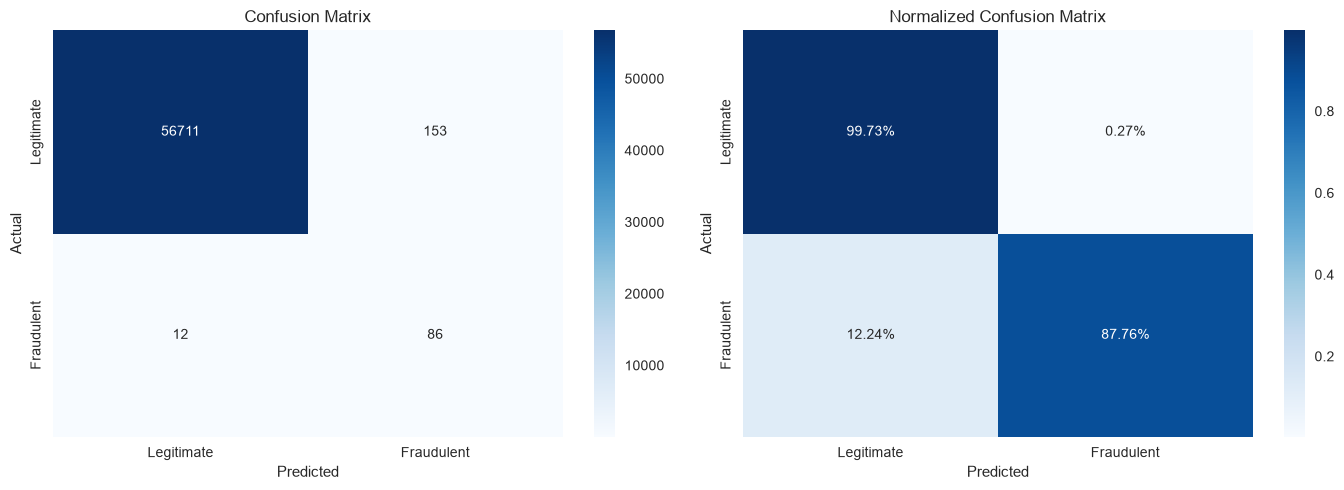

In [9]:
# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

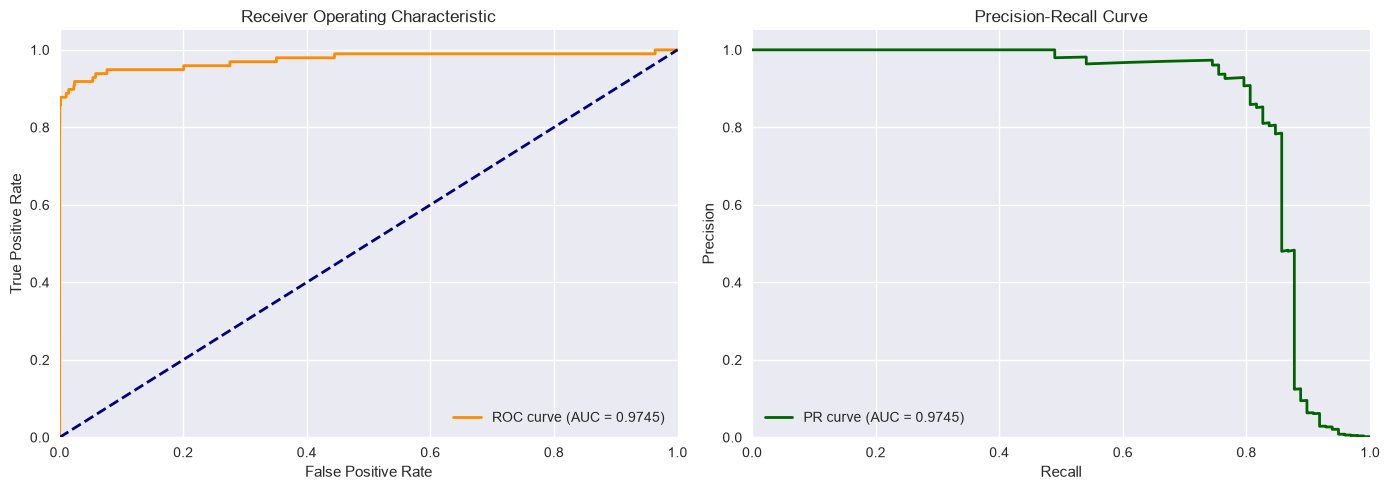

In [10]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = roc_auc_score(y_test, y_pred_proba)

axes[1].plot(recall, precision, color='darkgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True)

plt.tight_layout()
plt.show()

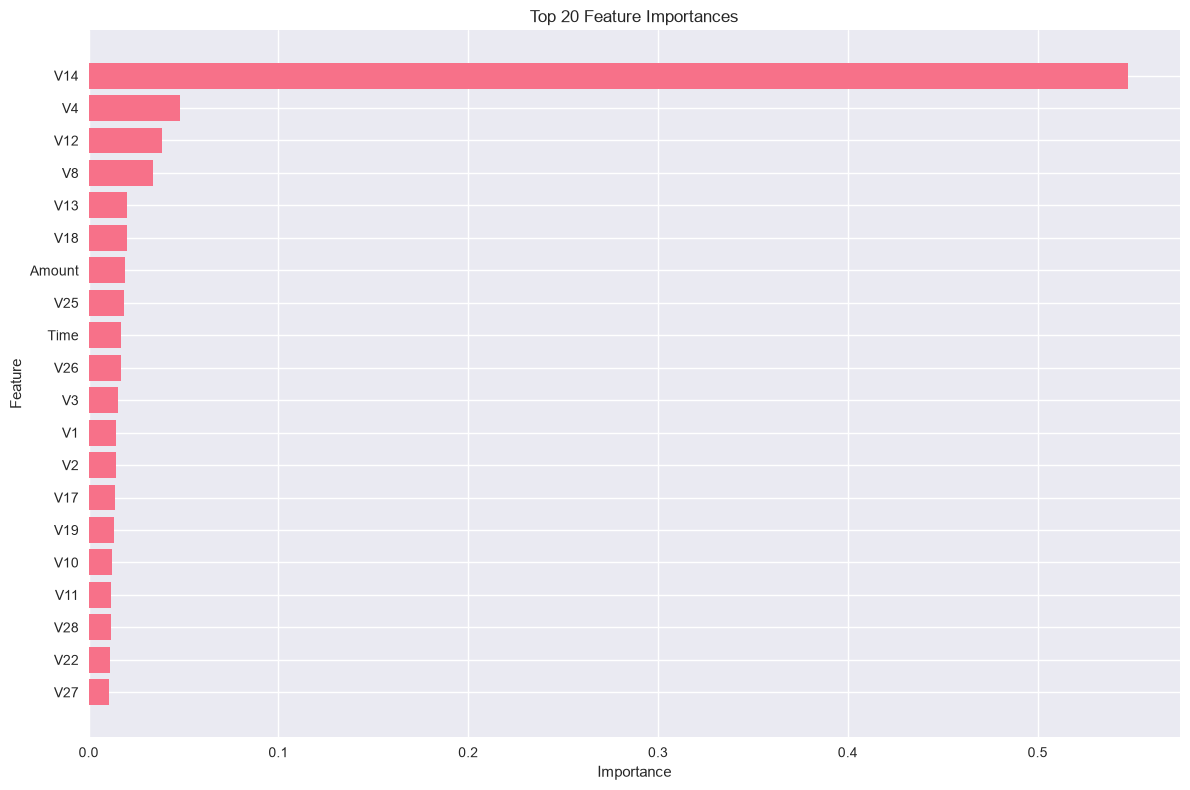


Top 10 important features:
   feature  importance
14     V14    0.547634
4       V4    0.048019
12     V12    0.038550
8       V8    0.033697
13     V13    0.020422
18     V18    0.020082
29  Amount    0.019335
25     V25    0.018446
0     Time    0.017211
26     V26    0.017135


In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 important features:')
print(feature_importance[:10])

In [12]:
# Save model
joblib.dump(xgb_model, '../data/xgb_model.pkl')
print('Model saved successfully!')

Model saved successfully!


In [13]:
# Summary statistics
tn, fp, fn, tp = cm.ravel()

print('='*50)
print('MODEL PERFORMANCE SUMMARY')
print('='*50)
print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}')
print(f'Precision: {tp/(tp+fp):.4f}')
print(f'Recall: {tp/(tp+fn):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print('='*50)
print(f'\nTrue Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')

MODEL PERFORMANCE SUMMARY
Accuracy: 0.9971
Precision: 0.3598
Recall: 0.8776
F1-Score: 0.5104
ROC-AUC: 0.9745

True Negatives: 56711
False Positives: 153
False Negatives: 12
True Positives: 86
